# Breast Cancer Regression (Deep Learning)
`mean radius` 수치(연속값)를 예측하는 딥러닝 모델

※ Regression은 y가 연속적인 숫자 → 원핫인코딩 없음, 출력 뉴런 1개, loss=mse

In [3]:
import pandas as pd
import numpy as np

path = '../../data/breast_cancer.csv'

df = pd.read_csv(path)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')] # 인덱스 컬럼 정리

# Regression: mean radius를 예측 대상(y)으로 사용
X = df.drop(['mean radius', 'label'], axis=1) # 분류형 라벨도 제외
y = df['mean radius']

print(y.describe())

count    569.000000
mean      14.127292
std        3.524049
min        6.981000
25%       11.700000
50%       13.370000
75%       15.780000
max       28.110000
Name: mean radius, dtype: float64


Epoch 1/50


c:\Users\kiw60\Desktop\intro-to-ai\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 158.8943 - mae: 12.2406 - val_loss: 134.0457 - val_mae: 11.2757
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 87.2740 - mae: 8.8365 - val_loss: 59.0957 - val_mae: 6.9612
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36.2286 - mae: 5.0753 - val_loss: 39.9636 - val_mae: 5.1820
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 26.2666 - mae: 4.1596 - val_loss: 32.1515 - val_mae: 4.6421
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20.6475 - mae: 3.6762 - val_loss: 28.6807 - val_mae: 4.3080
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20.0247 - mae: 3.6972 - val_loss: 26.5595 - val_mae: 4.0664
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16.4567 - mae: 3.2395 - val_loss: 21.3331 - val_mae: 3.6458
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 17.6445 - mae: 3.3594 - val_loss: 18.6077 - val_mae: 3.4165
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.21

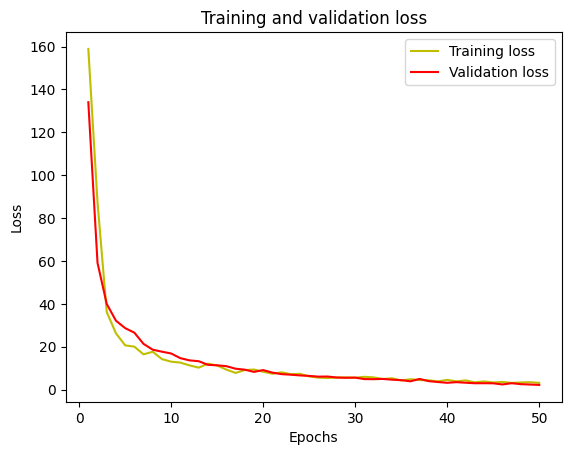

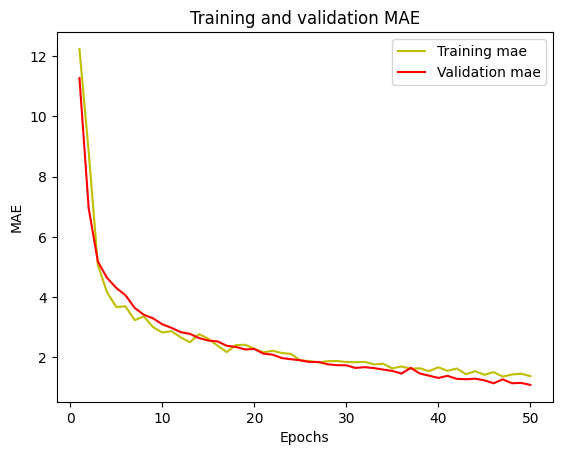

MSE  : 2.0213
MAE  : 0.9817
R²   : 0.8329


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

scaler = StandardScaler()
X = scaler.fit_transform(X)   # numpy 배열로 변환됨

# Regression은 원핫인코딩 없음 → y를 numpy 배열로만 변환
Y = y.values

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)   # Regression: 뉴런 1개, 활성화 함수 없음(linear)
])

model.compile(
    optimizer="adam",
    loss="mse",        # Regression 손실함수: Mean Squared Error
    metrics=["mae"]    # 평가지표: Mean Absolute Error
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

y_pred = model.predict(X_test).flatten()

# 학습 곡선
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(loss) + 1)

plt.plot(epochs_range, loss, 'y', label='Training loss')
plt.plot(epochs_range, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

mae = history.history['mae']
val_mae = history.history['val_mae']
plt.plot(epochs_range, mae, 'y', label='Training mae')
plt.plot(epochs_range, val_mae, 'r', label='Validation mae')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

# Accuracy of the predicted values
print(f'MSE  : {mean_squared_error(y_test, y_pred):.4f}')
print(f'MAE  : {mean_absolute_error(y_test, y_pred):.4f}')
print(f'R²   : {r2_score(y_test, y_pred):.4f}')